# SIP

`lamatrix` provides a way to fit "Simple Imaging Polynomials" for astronomy data. SIP are a set of polynomials that describe distortions in positions for images. 

To show how to use this object we will set up some fake data consisting of point sources on a grid. The point sources should land at their "true" positions, but in fact land at a distorted position in our detector.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(52)

# True grid
Y, X = np.mgrid[-20:20:200j, -20:20:201j]

In [6]:
# Distorted grid
# Here we use a simple, 2D, 3rd order polynomial
from lamatrix import Polynomial, Constant
distortion_model = (Constant() + Polynomial('x', order=3)) * (Constant() + Polynomial('y', order=3))

In [7]:
distortion_model

JointModel
	Constant()[n, 1]
	Polynomial(y)[n, 3]
	Polynomial(x)[n, 3]
	CrosstermModel(y, x)[n, 9]

In [8]:
w_x = np.random.normal(0, 0.1/distortion_model.design_matrix(x=np.asarray([20.]), y=np.asarray([20.]))[0])
w_y = np.random.normal(0, 0.1/distortion_model.design_matrix(x=np.asarray([20.]), y=np.asarray([20.]))[0])
A = distortion_model.design_matrix(x=X, y=Y)
Xt = X + A.dot(w_x)
Yt = Y + A.dot(w_y)

from lamatrix import SIP

Below we show the true grid (`X` and `Y`) and the points that we would measure due to some distortions in our detector. 

[Text(0.5, 0, 'X'), Text(0, 0.5, 'Y'), None]

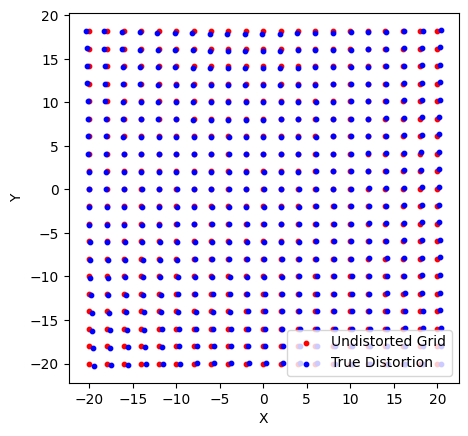

In [9]:
fig, ax = plt.subplots()
ax.scatter(X[::10, ::10], Y[::10, ::10], s=10, c='r', label='Undistorted Grid')
ax.scatter(Xt[::10, ::10], Yt[::10, ::10], s=10, c='b', label='True Distortion')
ax.legend()
ax.set(xlabel="X", ylabel="Y", aspect='equal')

To be able to fit this grid we need data consisting of astronomical sources. We make a grid of synthetic PSFs below

In [10]:
from lamatrix import Gaussian2D

In [11]:
Cx, Cy = np.mgrid[-20:20:20j, -20:20:20j]
data = np.sum([Gaussian2D(sigma_x=0.4, sigma_y=0.4).design_matrix(x=Xt - center_x, y=Yt - center_y).dot(amp)[:, :, 0] for center_x, center_y, amp in zip(Cx.ravel(), Cy.ravel(), np.ones(np.prod(Cx.shape)))], axis=0)
data += np.random.normal(0, 0.01, data.shape)
error = np.ones(data.shape) * 0.01

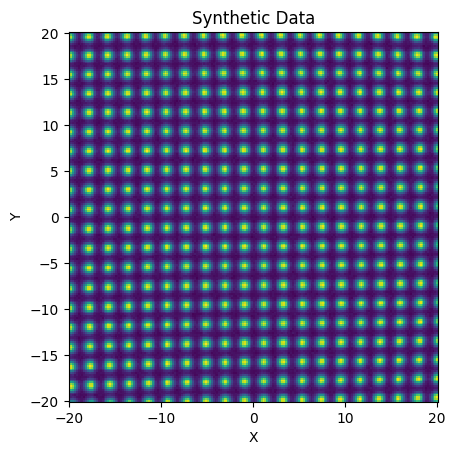

In [12]:
fig, ax = plt.subplots()
ax.pcolormesh(Y, X, data)
ax.set(xlabel="X", ylabel="Y", aspect='equal', title='Synthetic Data');

Here you can see the gentle distortion in the position of the PSFs, relative to the evenly spaced input grid.

To fit this we use a SIP model.

In [13]:
sip = SIP(order=3)

In [14]:
sip

SIP(y, x, dy, dx)[n, 56]

The SIP model requires $x$ and $y$, the positions of the sources on the detector in $x$ and $y$ respectively, and $\delta x$ and $\delta y$, the positions of the sources on the detector in $x$ and $y$ minus the expected source centers.

Below we extract the data around the expected (undistorted) position of each source

In [15]:
d, e, x, y, dx, dy = np.hstack([np.asarray([data, error, X, Y, X - center_x, Y - center_y])[:, np.hypot(X - center_x, Y - center_y) < 1] for center_x, center_y, amp in zip(Cx.ravel(), Cy.ravel(), np.ones(np.prod(Cx.shape)))])

Now we can use this to fit the data

Note that the SIP object fits **the log of the data**, so you should weight the errors accordingly.

In [16]:
sip.fit(x=x, y=y, dx=dx, dy=dy, data=np.log(d), errors=e/d, mask=d > 0)

/var/folders/bv/0t7fjlgx0mx3_3bdhxqzd7bmh_67k0/T/ipykernel_25384/1406739898.py:1: RuntimeWarning: invalid value encountered in log
  sip.fit(x=x, y=y, dx=dx, dy=dy, data=np.log(d), errors=e/d, mask=d > 0)


Now that the model is fit, we have access to the `mu_x` and `mu_y` parameters

In [17]:
sip.mu_x

DistributionContainer
	[(-0.05254, 0.00021), (0.006728, 2.9e-05), (-4.73e-05, 1.1e-06), (7.19e-06, 1.1e-07), (0.000543, 2.9e-05), (-0.0002485, 3.9e-06), (-3.84e-06, 1.6e-07), (-5.33e-07, 1.4e-08), (-0.0001076, 1.1e-06), (5.67e-06, 1.5e-07), (-7.355e-07, 6.2e-09), (-1.217e-08, 5.6e-10), (-1.781e-05, 1.1e-07), (-1.06e-07, 1.4e-08), (-9.7e-10, 5.7e-10), (1.13e-10, 5.3e-11)]

These are the SIP model weights as a function of $x$ and $y$. To convert this back into a polynomial model you can use the `mu_x_to_Model` or `mu_y_to_Model` functions

In [18]:
sip.mu_x_to_Model()

JointModel
	Constant()[n, 1]
	Polynomial(y)[n, 3]
	Polynomial(x)[n, 3]
	CrosstermModel(y, x)[n, 9]

These are the weights for the distortion model, back into a 2D polynomial. 

We can use these models to calculate our estimated distortion grid `Xc` and `Yc`.

In [19]:
Xc, Yc = X - sip.mu_x_to_Model().evaluate(x=X, y=Y), Y - sip.mu_y_to_Model().evaluate(x=X, y=Y)

[Text(0.5, 0, 'X'), Text(0, 0.5, 'Y'), None]

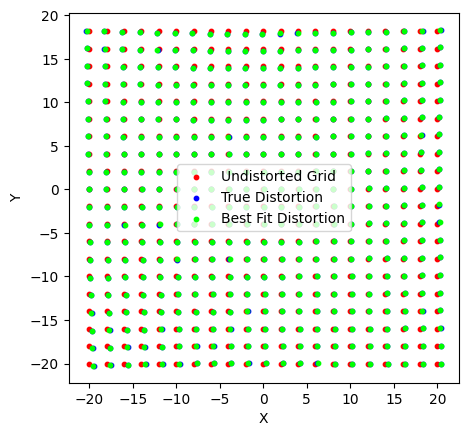

In [21]:
fig, ax = plt.subplots()
ax.scatter(X[::10, ::10], Y[::10, ::10], s=10, c='r', label='Undistorted Grid')
ax.scatter(Xt[::10, ::10], Yt[::10, ::10], s=10, c='b', label='True Distortion')
ax.scatter(Xc[::10, ::10], Yc[::10, ::10], s=10, c='lime', label='Best Fit Distortion')
ax.legend()
ax.set(xlabel="X", ylabel="Y", aspect='equal')

We've fit the distortion and found a very good fit. We can now use this model to translate between the undistorted and the distorted space.

Assuming that you have the `astropy` package installed, you are able to convert this model into an `astrop.sip.SIP` class, which will let you store this information as a FITS file for use in your astronomy data.

In [22]:
sip.to_astropySip(imshape=data.shape, crpix=(100, 100))

This model is designed to help you convert astronomy images where you have isolated sources at known positions and brightnesses into SIP models. Note you should read our accompanying paper to understand how this works and how to use this in practice. 

This model only works when

1. Sources are isolated (no crowding)
2. Pixels are used where there is a high signal to noise (no low signal to noise pixels)
3. All background has been subtracted. The only source of signal is the stars.
4. All source have been normalized such that their integrated flux is 1